Companion notebook for *A Probabilistic Mixture Model for Evaluating Sound Localisation Performance in the Median Plane* (Sztandera, Picinali, Barumerli, Forum Acusticum 2026). Run it from the repository root; it reads `data/AXD_measured.csv` (see `data/README.md`).

# Prior Recovery Notebook

Tests whether the three parameters of the extended mixture model — `w`, `κ`, `κ_prior` — can be jointly identified from synthetic data.

**Extended model:**
$$p(\phi | \phi_t) \propto [w \cdot \text{VM}(\phi_t, \kappa) + (1-w) \cdot \text{VM}(\pi - \phi_t, \kappa)] \cdot [0.5 \cdot \text{VM}(0, \kappa_\text{prior}) + 0.5 \cdot \text{VM}(\pi, \kappa_\text{prior})]$$

Via the von Mises addition theorem this expands to a **4-component VM mixture** with analytic weights — no grid needed.

## Step 0 — Imports and setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.special import i0
from scipy.stats.qmc import LatinHypercube
from scipy.stats import pearsonr

from bayesian_metric import (sigma_to_kappa, kappa_to_sigma, vm_product,
                             fit_mixture_querr, fit_mixture_with_prior,
                             sample_from_prior_mixture, eval_mixture)
from metrics import wrap_polar_angle

SEED = 42
N_TRIALS = 45
rng = np.random.default_rng(SEED)

# Load AXD data — central targets only
obs_tbl = pd.read_csv('data/AXD_measured.csv')   # Measured condition only
obs_tbl = obs_tbl[obs_tbl['participant'] != 'P0247'].reset_index(drop=True)

central_rows = obs_tbl[
    np.abs(obs_tbl['lat_target']) <= 30.0
][['lat_target', 'pol_target']].reset_index(drop=True)

print(f'Central target pool: {len(central_rows)} rows')

Central target pool: 2349 rows


## Step 1 — New functions

All three functions are analytic — no grid, no numerical integration.

### Step 1 — Coherence checks

In [2]:
# 1a. vm_product collinear case: mu1=mu2=0, result should be R=kappa1+kappa2, mu*=0
kappa_test, kappa_prior_test = sigma_to_kappa(25.0), sigma_to_kappa(30.0)
R_test, mu_test = vm_product(0.0, kappa_test, 0.0, kappa_prior_test)
print(f'vm_product collinear: R={R_test:.4f} (expected {kappa_test+kappa_prior_test:.4f}), '
      f'mu*={np.rad2deg(mu_test):.4f}° (expected 0°)')

# 1b. sample_from_prior_mixture with kappa_prior≈0 should resemble original model
# Weights should approach [w/2, w/2, (1-w)/2, (1-w)/2]
w_test = 0.8
eps_kp = 1e-6
pt_test = np.array([0.0])
pm_test = wrap_polar_angle(np.pi - pt_test)
R_A0, _ = vm_product(pt_test, kappa_test, 0.0,   eps_kp)
R_B0, _ = vm_product(pt_test, kappa_test, np.pi, eps_kp)
I0_A0, I0_B0 = i0(R_A0), i0(R_B0)
denom0 = I0_A0 + I0_B0
alpha0 = np.array([
    w_test * I0_A0 / denom0,
    w_test * I0_B0 / denom0,
    (1 - w_test) * I0_B0 / denom0,
    (1 - w_test) * I0_A0 / denom0,
]).flatten()
print(f'Weights at kappa_prior≈0: {alpha0.round(3)} '
      f'(expected [{w_test/2:.2f}, {w_test/2:.2f}, {(1-w_test)/2:.2f}, {(1-w_test)/2:.2f}])')

# 1c. fit_mixture_with_prior smoke test on minimal df
df_test = pd.DataFrame({
    'lat_target':   np.zeros(20),
    'pol_target':   np.zeros(20),
    'pol_response': np.random.default_rng(0).uniform(-90, 90, 20),
})
res_test = fit_mixture_with_prior(df_test)
print(f'fit_mixture_with_prior smoke test: nll={res_test["nll"]:.2f}, '
      f'w_hat={res_test["w_hat"]:.3f}, sigma_hat={res_test["sigma_hat"]:.1f}°, '
      f'sigma_prior_hat={res_test["sigma_prior_hat"]:.1f}°')

vm_product collinear: R=10.0362 (expected 10.0362), mu*=0.0000° (expected 0°)
Weights at kappa_prior≈0: [0.4 0.4 0.1 0.1] (expected [0.40, 0.40, 0.10, 0.10])


fit_mixture_with_prior smoke test: nll=30.34, w_hat=1.000, sigma_hat=63.3°, sigma_prior_hat=100.0°


## Step 2 — Sanity check: visualise the generative model

Rows: two target elevations (φ_t = 0°, 90°). Columns: three κ_prior strengths (flat, weak, strong).

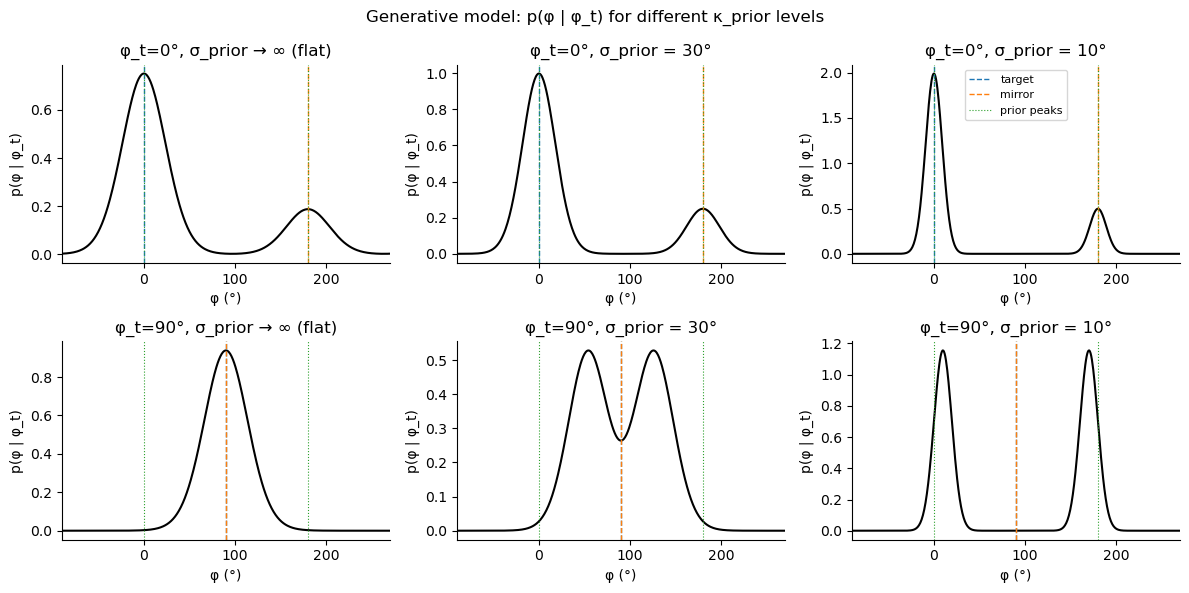


Coherence: at φ_t=0° with strong prior, peak at 0.2° (expected ~0°)
Coherence: at φ_t=90° with strong prior, main peak at 9.6° (expected near 0° or 180°)


In [3]:
phi_grid = np.linspace(-np.pi / 2, 3 * np.pi / 2, 500)

w_vis    = 0.8
kappa_vis = sigma_to_kappa(25.0)
kappa_prior_levels = [1e-6, sigma_to_kappa(30.0), sigma_to_kappa(10.0)]
kp_labels = ['σ_prior → ∞ (flat)', 'σ_prior = 30°', 'σ_prior = 10°']
target_elevs_deg = [0.0, 90.0]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=False)
fig.suptitle('Generative model: p(φ | φ_t) for different κ_prior levels', fontsize=12)

for row, phi_t_deg in enumerate(target_elevs_deg):
    phi_t = np.deg2rad(phi_t_deg)
    for col, (kp, kp_lbl) in enumerate(zip(kappa_prior_levels, kp_labels)):
        ax = axes[row, col]
        p  = eval_mixture(phi_grid, phi_t, w_vis, kappa_vis, kp)
        ax.plot(np.rad2deg(phi_grid), p, 'k', lw=1.5)
        ax.axvline(phi_t_deg,            color='tab:blue',   lw=1, ls='--', label='target')
        ax.axvline(180 - phi_t_deg,      color='tab:orange', lw=1, ls='--', label='mirror')
        ax.axvline(0,   color='tab:green', lw=0.8, ls=':')
        ax.axvline(180, color='tab:green', lw=0.8, ls=':', label='prior peaks')
        ax.set_xlim(-90, 270)
        ax.set_xlabel('φ (°)')
        ax.set_ylabel('p(φ | φ_t)')
        ax.set_title(f'φ_t={phi_t_deg:.0f}°, {kp_lbl}')
        ax.spines[['top', 'right']].set_visible(False)
        if row == 0 and col == 2:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Coherence check: at phi_t=0, strong prior → peak at 0
p_strong = eval_mixture(phi_grid, 0.0, w_vis, kappa_vis, sigma_to_kappa(10.0))
peak_deg = np.rad2deg(phi_grid[np.argmax(p_strong)])
print(f'\nCoherence: at φ_t=0° with strong prior, peak at {peak_deg:.1f}° (expected ~0°)')

# At phi_t=90, strong prior → mass near 0 and 180
p_90 = eval_mixture(phi_grid, np.deg2rad(90.0), w_vis, kappa_vis, sigma_to_kappa(10.0))
peak_90_deg = np.rad2deg(phi_grid[np.argmax(p_90)])
print(f'Coherence: at φ_t=90° with strong prior, main peak at {peak_90_deg:.1f}° (expected near 0° or 180°)')

## Step 3 — Synthetic data generation (28 participants via LHS)

Pairwise correlations between true parameters:
             w      σ  σ_prior
w        1.000  0.207    0.316
σ        0.207  1.000   -0.204
σ_prior  0.316 -0.204    1.000

All dfs have 99 rows: True

Head of participant 0:
   lat_target  pol_target  pol_response
0         0.0       180.0      7.004389
1       -30.0       180.0    174.685733
2         0.0       -30.0    -65.912838
3         0.0       -30.0    -24.844010
4         0.0       150.0    169.708278


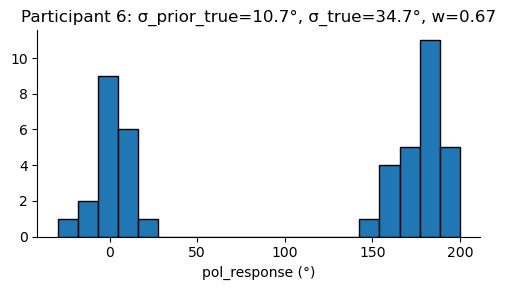

In [4]:
# --- LHS parameter sampling ---
sampler = LatinHypercube(d=3, seed=SEED)
sample  = sampler.random(n=28)

w_true           = 0.55 + sample[:, 0] * 0.40   # [0.55, 0.95]
sigma_true       = 10   + sample[:, 1] * 45      # [10°, 55°]
sigma_prior_true = 10   + sample[:, 2] * 80      # [10°, 90°]

kappa_true       = np.array([sigma_to_kappa(s) for s in sigma_true])
kappa_prior_true = np.array([sigma_to_kappa(s) for s in sigma_prior_true])

# Verify near-zero pairwise correlation
corr_matrix = np.corrcoef([w_true, sigma_true, sigma_prior_true])
print('Pairwise correlations between true parameters:')
print(pd.DataFrame(corr_matrix,
                   index=['w', 'σ', 'σ_prior'],
                   columns=['w', 'σ', 'σ_prior']).round(3))

# --- Generate 28 synthetic participants ---
seeds = rng.integers(0, 2**31, 28)

synth_dfs = []
for i in range(28):
    rng_i   = np.random.default_rng(int(seeds[i]))
    idx     = rng_i.choice(len(central_rows), size=N_TRIALS, replace=True)
    lat_t   = central_rows.iloc[idx]['lat_target'].values
    pol_t   = central_rows.iloc[idx]['pol_target'].values
    pol_t_r = wrap_polar_angle(np.deg2rad(pol_t))

    pol_resp_r = sample_from_prior_mixture(
        pol_t_r, w_true[i], kappa_true[i], kappa_prior_true[i], rng_i
    )
    synth_dfs.append(pd.DataFrame({
        'lat_target':   lat_t,
        'pol_target':   pol_t,
        'pol_response': np.rad2deg(pol_resp_r),
    }))

# Coherence checks
print(f'\nAll dfs have 99 rows: {all(len(df) == N_TRIALS for df in synth_dfs)}')
print('\nHead of participant 0:')
print(synth_dfs[0].head())

# Histogram for the participant with strongest prior (smallest sigma_prior_true)
idx_strong = int(np.argmin(sigma_prior_true))
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(synth_dfs[idx_strong]['pol_response'], bins=20, edgecolor='black')
ax.set_xlabel('pol_response (°)')
ax.set_title(f'Participant {idx_strong}: σ_prior_true={sigma_prior_true[idx_strong]:.1f}°, '
             f'σ_true={sigma_true[idx_strong]:.1f}°, w={w_true[idx_strong]:.2f}')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Step 4 — Fit both models in parallel

In [5]:
print('Fitting extended model (w, κ, κ_prior)...')
results_ext = joblib.Parallel(n_jobs=-1, prefer='threads')(
    joblib.delayed(fit_mixture_with_prior)(df) for df in synth_dfs
)

print('Fitting original model (w, κ)...')
results_orig = joblib.Parallel(n_jobs=-1, prefer='threads')(
    joblib.delayed(fit_mixture_querr)(df) for df in synth_dfs
)

results_df = pd.DataFrame({
    'participant_id':   np.arange(28),
    'w_true':           w_true,
    'sigma_true':       sigma_true,
    'sigma_prior_true': sigma_prior_true,
    # extended model
    'w_hat':            [r['w_hat']           for r in results_ext],
    'sigma_hat':        [r['sigma_hat']        for r in results_ext],
    'sigma_prior_hat':  [r['sigma_prior_hat']  for r in results_ext],
    # original model
    'w_hat_orig':       [r['w_hat']   for r in results_orig],
    'sigma_hat_orig':   [r['sigma_hat'] for r in results_orig],
})

print(results_df.round(2).to_string())

# Coherence check
idx_strong = int(np.argmin(results_df['sigma_prior_true']))
idx_weak   = int(np.argmax(results_df['sigma_prior_true']))
print(f'\nStrongest prior (σ_prior_true={results_df.loc[idx_strong,"sigma_prior_true"]:.1f}°): '
      f'σ_prior_hat={results_df.loc[idx_strong,"sigma_prior_hat"]:.1f}°')
print(f'Weakest prior  (σ_prior_true={results_df.loc[idx_weak,"sigma_prior_true"]:.1f}°): '
      f'σ_prior_hat={results_df.loc[idx_weak,"sigma_prior_hat"]:.1f}°')

Fitting extended model (w, κ, κ_prior)...


Fitting original model (w, κ)...


    participant_id  w_true  sigma_true  sigma_prior_true  w_hat  sigma_hat  sigma_prior_hat  w_hat_orig  sigma_hat_orig
0                0    0.62       20.54             36.12   0.60      20.40            33.84        0.60           20.45
1                1    0.87       45.21             70.07   0.74      49.92            61.54        0.74           48.68
2                2    0.64       52.13             21.06   0.63      47.77            19.50        0.63           47.82
3                3    0.60       27.08             67.35   0.65      28.07            67.81        0.65           27.68
4                4    0.77       47.25             74.45   0.86      43.87            66.34        0.86           42.33
5                5    0.75       41.25             66.96   0.66      37.69            41.57        0.66           33.66
6                6    0.67       34.70             10.69   0.58      34.97            11.53        0.58           40.71
7                7    0.83       38.98  

## Step 5 — Parameter recovery plots

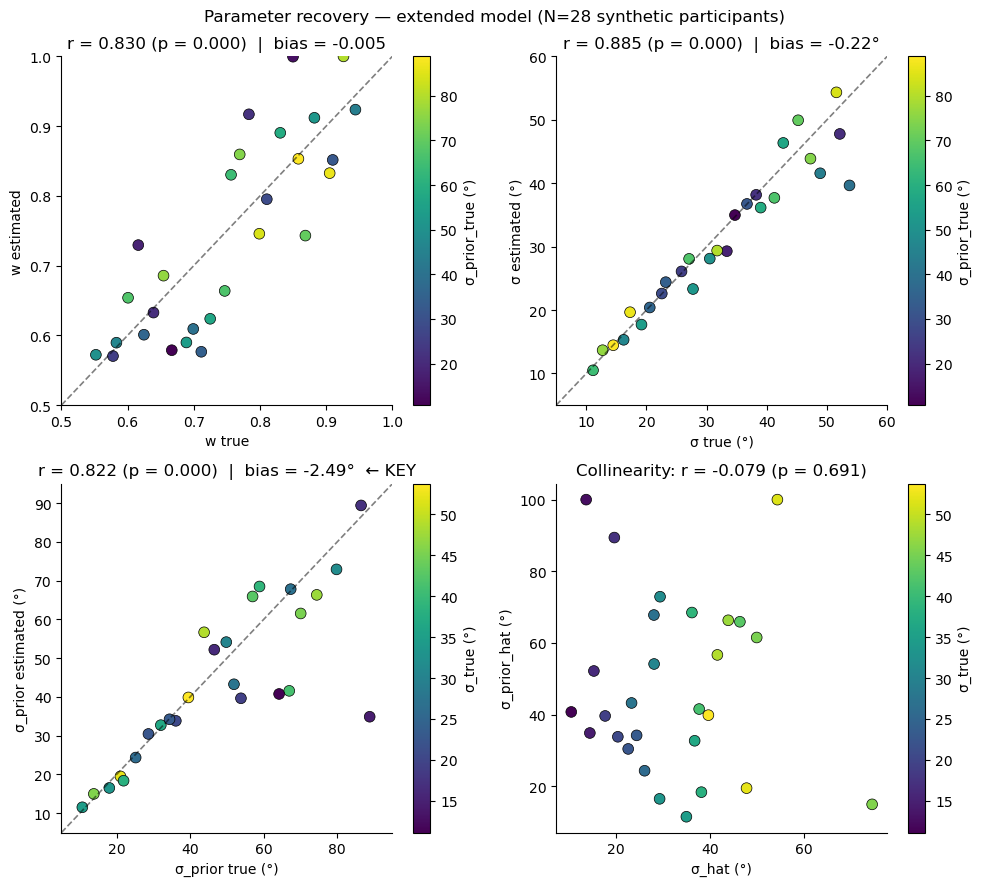


Coherence summary:
  5a r(w)            = 0.830  (want ≥ 0.9)
  5b r(σ)            = 0.885  (want ≥ 0.9)
  5c r(σ_prior)      = 0.822  p = 0.0000  (key test — identifiability)
  5d collinearity r  = -0.079  p = 0.6912  (want near 0)
  5e collinearity sigma, w r  = 0.254  p = 0.1925  (want near 0)
  5e collinearity sigma_prior, w r  = 0.107  p = 0.5872  (want near 0)


In [6]:
logit = lambda p: np.log(p / (1 - p))

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
fig.suptitle('Parameter recovery — extended model (N=28 synthetic participants)', fontsize=12)

cmap = plt.cm.viridis

# --- 5a: w recovery ---
ax = axes[0, 0]
sc = ax.scatter(results_df['w_true'], results_df['w_hat'],
                c=results_df['sigma_prior_true'], cmap=cmap, s=60,
                edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='σ_prior_true (°)')
lims = [0.5, 1.0]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
r_w, p_w = pearsonr(results_df['w_true'], results_df['w_hat'])
bias_w = np.mean(results_df['w_hat'] - results_df['w_true'])
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('w true'); ax.set_ylabel('w estimated')
ax.set_title(f'r = {r_w:.3f} (p = {p_w:.3f})  |  bias = {bias_w:+.3f}')
ax.spines[['top', 'right']].set_visible(False)

# --- 5b: sigma recovery ---
ax = axes[0, 1]
sc = ax.scatter(results_df['sigma_true'], results_df['sigma_hat'],
                c=results_df['sigma_prior_true'], cmap=cmap, s=60,
                edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='σ_prior_true (°)')
lims_s = [5, 60]
ax.plot(lims_s, lims_s, 'k--', lw=1.2, alpha=0.5)
r_s, p_s = pearsonr(results_df['sigma_true'], results_df['sigma_hat'])
bias_s = np.mean(results_df['sigma_hat'] - results_df['sigma_true'])
ax.set_xlim(lims_s); ax.set_ylim(lims_s)
ax.set_xlabel('σ true (°)'); ax.set_ylabel('σ estimated (°)')
ax.set_title(f'r = {r_s:.3f} (p = {p_s:.3f})  |  bias = {bias_s:+.2f}°')
ax.spines[['top', 'right']].set_visible(False)

# --- 5c: sigma_prior recovery (key identifiability check) ---
ax = axes[1, 0]
sc = ax.scatter(results_df['sigma_prior_true'], results_df['sigma_prior_hat'],
                c=results_df['sigma_true'], cmap=cmap, s=60,
                edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='σ_true (°)')
lims_p = [5, 95]
ax.plot(lims_p, lims_p, 'k--', lw=1.2, alpha=0.5)
r_p, p_p = pearsonr(results_df['sigma_prior_true'], results_df['sigma_prior_hat'])
bias_p = np.mean(results_df['sigma_prior_hat'] - results_df['sigma_prior_true'])
ax.set_xlim(lims_p); ax.set_ylim(lims_p)
ax.set_xlabel('σ_prior true (°)'); ax.set_ylabel('σ_prior estimated (°)')
ax.set_title(f'r = {r_p:.3f} (p = {p_p:.3f})  |  bias = {bias_p:+.2f}°  ← KEY')
ax.spines[['top', 'right']].set_visible(False)

# --- 5d: sigma_hat vs sigma_prior_hat (collinearity check) ---
ax = axes[1, 1]
sc = ax.scatter(results_df['sigma_hat'], results_df['sigma_prior_hat'],
                c=results_df['sigma_true'], cmap=cmap, s=60,
                edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='σ_true (°)')
r_col, p_col = pearsonr(results_df['sigma_hat'], results_df['sigma_prior_hat'])
ax.set_xlabel('σ_hat (°)'); ax.set_ylabel('σ_prior_hat (°)')
ax.set_title(f'Collinearity: r = {r_col:.3f} (p = {p_col:.3f})')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nCoherence summary:')
print(f'  5a r(w)            = {r_w:.3f}  (want ≥ 0.9)')
print(f'  5b r(σ)            = {r_s:.3f}  (want ≥ 0.9)')
print(f'  5c r(σ_prior)      = {r_p:.3f}  p = {p_p:.4f}  (key test — identifiability)')
print(f'  5d collinearity r  = {r_col:.3f}  p = {p_col:.4f}  (want near 0)')

r_col, p_col = pearsonr(results_df['sigma_hat'], results_df['w_hat'])

print(f'  5e collinearity sigma, w r  = {r_col:.3f}  p = {p_col:.4f}  (want near 0)')

r_col, p_col = pearsonr(results_df['sigma_prior_hat'], results_df['w_hat'])

print(f'  5e collinearity sigma_prior, w r  = {r_col:.3f}  p = {p_col:.4f}  (want near 0)')

## Step 6 — Original vs extended model comparison

Does ignoring the spatial prior bias σ̂ or ŵ?

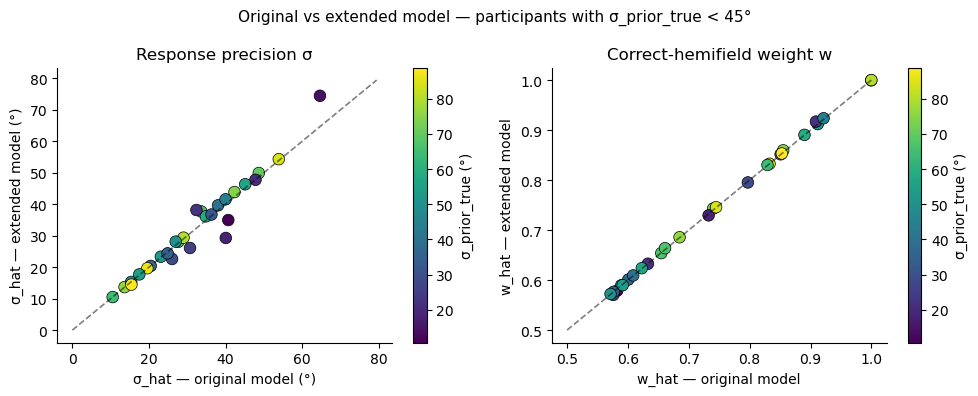

Mean difference orig − extended:
  σ_hat:  -0.18°  (positive = original overestimates σ)
  w_hat:  -0.000   (positive = original overestimates w)


In [7]:
# Subset with non-trivial prior
strong_mask = results_df['sigma_prior_true'] < 100
sub = results_df[strong_mask].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Original vs extended model — participants with σ_prior_true < 45°', fontsize=11)

# σ_hat comparison
ax = axes[0]
sc = ax.scatter(sub['sigma_hat_orig'], sub['sigma_hat'],
                c=sub['sigma_prior_true'], cmap=cmap, s=70,
                edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='σ_prior_true (°)')
lims_c = [0, max(sub['sigma_hat_orig'].max(), sub['sigma_hat'].max()) + 5]
ax.plot(lims_c, lims_c, 'k--', lw=1.2, alpha=0.5)
ax.set_xlabel('σ_hat — original model (°)')
ax.set_ylabel('σ_hat — extended model (°)')
ax.set_title('Response precision σ')
ax.spines[['top', 'right']].set_visible(False)

# w_hat comparison
ax = axes[1]
sc = ax.scatter(sub['w_hat_orig'], sub['w_hat'],
                c=sub['sigma_prior_true'], cmap=cmap, s=70,
                edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='σ_prior_true (°)')
lims_w = [0.5, 1.0]
ax.plot(lims_w, lims_w, 'k--', lw=1.2, alpha=0.5)
ax.set_xlabel('w_hat — original model')
ax.set_ylabel('w_hat — extended model')
ax.set_title('Correct-hemifield weight w')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Bias estimates
sigma_bias_orig_vs_ext = np.mean(sub['sigma_hat_orig'] - sub['sigma_hat'])
w_bias_orig_vs_ext     = np.mean(sub['w_hat_orig']     - sub['w_hat'])
print(f'Mean difference orig − extended:')
print(f'  σ_hat:  {sigma_bias_orig_vs_ext:+.2f}°  (positive = original overestimates σ)')
print(f'  w_hat:  {w_bias_orig_vs_ext:+.3f}   (positive = original overestimates w)')

## Step 7 — Summary table

In [8]:
summary = results_df[[
    'participant_id', 'w_true', 'sigma_true', 'sigma_prior_true',
    'w_hat', 'sigma_hat', 'sigma_prior_hat',
]].copy()

summary['bias_w']       = summary['w_hat']           - summary['w_true']
summary['bias_sigma']   = summary['sigma_hat']        - summary['sigma_true']
summary['bias_sp']      = summary['sigma_prior_hat']  - summary['sigma_prior_true']

display_cols = [
    'participant_id',
    'w_true', 'sigma_true', 'sigma_prior_true',
    'w_hat', 'bias_w',
    'sigma_hat', 'bias_sigma',
    'sigma_prior_hat', 'bias_sp',
]
print(summary[display_cols].round(2).to_string(index=False))

# Pairwise Pearson r between recovered parameters
# print('\nPairwise Pearson r between recovered parameters:')
# rec_corr = np.corrcoef([
#     results_df['w_hat'],
#     results_df['sigma_hat'],
#     results_df['sigma_prior_hat'],
# ])
# print(pd.DataFrame(rec_corr,
#                    index=['w_hat', 'σ_hat', 'σ_prior_hat'],
#                    columns=['w_hat', 'σ_hat', 'σ_prior_hat']).round(3))

# print('\\nPairwise Pearson r between recovered parameters:')
# rec_corr = np.corrcoef([
#     results_df['w_hat'],
#     results_df['sigma_hat'],
#     results_df['sigma_prior_hat'],
# ])
# print(pd.DataFrame(rec_corr,
#                    index=['w_hat', 'σ_hat', 'σ_prior_hat'],
#                    columns=['w_hat', 'σ_hat', 'σ_prior_hat']).round(3))

cols  = ['w_hat', 'sigma_hat', 'sigma_prior_hat']
labels = ['w_hat', 'σ_hat', 'σ_prior_hat']
n = len(cols)
r_mat = np.ones((n, n))
p_mat = np.ones((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            r_mat[i, j], p_mat[i, j] = pearsonr(results_df[cols[i]], results_df[cols[j]])

print('Pearson r:')
print(pd.DataFrame(r_mat, index=labels, columns=labels).round(3))
print('p-values:')
print(pd.DataFrame(p_mat, index=labels, columns=labels).round(4))

 participant_id  w_true  sigma_true  sigma_prior_true  w_hat  bias_w  sigma_hat  bias_sigma  sigma_prior_hat  bias_sp
              0    0.62       20.54             36.12   0.60   -0.02      20.40       -0.15            33.84    -2.28
              1    0.87       45.21             70.07   0.74   -0.13      49.92        4.72            61.54    -8.53
              2    0.64       52.13             21.06   0.63   -0.01      47.77       -4.36            19.50    -1.56
              3    0.60       27.08             67.35   0.65    0.05      28.07        0.98            67.81     0.46
              4    0.77       47.25             74.45   0.86    0.09      43.87       -3.38            66.34    -8.11
              5    0.75       41.25             66.96   0.66   -0.08      37.69       -3.56            41.57   -25.39
              6    0.67       34.70             10.69   0.58   -0.09      34.97        0.27            11.53     0.84
              7    0.83       38.98             58.88   